# Model Comparison — RF vs Logistic Regression

Compares Random Forest and L2-penalised Logistic Regression for predicting
berm **condition** (Intact) and **vegetation response** (Effective).

**Workflow:**
1. Define predictor scenarios (geomorphology, soil, length, all combined)
2. Baseline: fit RF + Logistic across all scenarios (CV AUC comparison)
3. Feature selection via RFECV (logistic backbone) on the "all predictors" set
4. Refit both models on RFECV-selected features and compare
5. Feature importance: RF permutation importance + Logistic |coefficients|

Loads `../data/merged.csv` produced by `data processing - condition vegetation.ipynb`.

In [1]:
# ── 1. Imports ─────────────────────────────────────────────────────────────
import sys as _sys
_sys.path.insert(0, '../src')
from constants import (
    INTACT_COL, DEGRADED_COL,
    MODEL_CLR_CONDITION, MODEL_CLR_VEGRESPONSE, MODEL_CLR_CHANCE,
)
from analysis import (
    fit_rf_binary, _unique_preserve, _coerce_binary,
    PRETTY_LABELS, _clean_predictor_name,
)
from registry import register_outcomes_figure

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance
from IPython.display import display

pd.set_option('display.max_columns', 50)
print('Imports OK')

Imports OK


In [2]:
# ── 2. Load data ──────────────────────────────────────────────────────────
data = pd.read_csv('../data/merged.csv')
df = data.loc[data['Structure_'].isna()].copy() if 'Structure_' in data.columns else data.copy()
print(f'Loaded {len(data):,} rows → df: {len(df):,} rows (after dropping artificial structures)')

Loaded 775 rows → df: 743 rows (after dropping artificial structures)


In [3]:
# ── 3. Predictor scenario definitions ─────────────────────────────────────
treat_as = {
    'Shape_Leng': 'numeric',
    'High_Clay':  'categorical',
}

_geo_preds  = ['Landform', 'slope_200', 'FA_30_max']
_soil_preds = ['Texture', 'Soil_Development', 'TypicalProfile']
_len_preds  = ['Shape_Leng', 'Berm_Length_Class']
_all_preds  = _unique_preserve(_geo_preds + _soil_preds + _len_preds)

scenario_predictors = {
    'landscape_geomorphology_only': _geo_preds,
    'soil_only':                    _soil_preds,
    'shape_length_only':            _len_preds,
    'all_predictors':               _all_preds,
}

_targets = ['Intact', 'Effective']
print(f'All predictors: {_all_preds}')
print(f'Targets: {_targets}')

All predictors: ['Landform', 'slope_200', 'FA_30_max', 'Texture', 'Soil_Development', 'TypicalProfile', 'Shape_Leng', 'Berm_Length_Class']
Targets: ['Intact', 'Effective']


In [4]:
# ── 4. Unified model pipeline builder ─────────────────────────────────────

def _build_pipeline(model_type, predictors, treat_as_map=None):
    """
    Build a sklearn Pipeline for either RF or Logistic regression.

    Parameters
    ----------
    model_type : {'RF', 'Logistic'}
    predictors : list[str]
    treat_as_map : dict, optional

    Returns
    -------
    Pipeline
    """
    treat_as_map = treat_as_map or {}
    cat_cols, num_cols = [], []
    for c in predictors:
        ta = treat_as_map.get(c)
        if ta == 'categorical':
            cat_cols.append(c)
        elif ta == 'numeric':
            num_cols.append(c)
        elif df[c].dtype == object or str(df[c].dtype).startswith('category'):
            cat_cols.append(c)
        else:
            num_cols.append(c)

    pre = ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('impute', SimpleImputer(strategy='median')),
                ('scale', StandardScaler()),
            ]), num_cols),
            ('cat', Pipeline([
                ('impute', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
            ]), cat_cols),
        ],
        remainder='drop',
    )

    if model_type == 'RF':
        clf = RandomForestClassifier(
            n_estimators=300, min_samples_leaf=2,
            class_weight='balanced', random_state=0, n_jobs=-1,
        )
    elif model_type == 'Logistic':
        clf = LogisticRegression(
            C=1.0, penalty='l2', max_iter=2000,
            class_weight='balanced', solver='lbfgs', random_state=0,
        )
    else:
        raise ValueError(f'Unknown model_type: {model_type}')

    return Pipeline([('pre', pre), ('clf', clf)])


def _fit_and_evaluate(model_type, predictors, target, treat_as_map=None,
                      test_size=0.25, random_state=0):
    """
    Fit a pipeline on df, return (pipeline, metrics_dict, pi_series).

    metrics_dict has keys 'cv' (dict of (mean, sd) tuples) and 'holdout' (dict).
    pi_series is permutation importance on the holdout set.
    """
    treat_as_map = treat_as_map or {}
    sub = df[predictors + [target]].copy()
    sub[target] = _coerce_binary(sub[target])
    sub = sub.dropna(subset=[target])

    X = sub[predictors]
    yv = sub[target].astype(int)

    pipe = _build_pipeline(model_type, predictors, treat_as_map)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, yv, test_size=test_size, stratify=yv, random_state=random_state)
    pipe.fit(X_tr, y_tr)

    holdout_auc = roc_auc_score(y_te, pipe.predict_proba(X_te)[:, 1])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    cv_scores = cross_validate(
        pipe, X, yv, cv=cv,
        scoring={'auc': 'roc_auc', 'bal_acc': 'balanced_accuracy', 'f1': 'f1'},
        n_jobs=-1, return_train_score=False,
    )
    cv_summary = {
        k.replace('test_', ''): (float(np.mean(v)), float(np.std(v)))
        for k, v in cv_scores.items() if k.startswith('test_')
    }

    pi = permutation_importance(
        pipe, X_te, y_te, scoring='roc_auc',
        n_repeats=30, random_state=random_state, n_jobs=-1,
    )
    pi_series = pd.Series(pi.importances_mean, index=predictors).sort_values(ascending=False)

    metrics = {
        'cv': cv_summary,
        'holdout': {'auc': float(holdout_auc)},
        'n': int(len(X)),
    }
    return pipe, metrics, pi_series


print('Pipeline builder & evaluator defined')

Pipeline builder & evaluator defined


## Baseline: all scenarios × both models

In [5]:
# ── 5. Baseline scenario sweep ────────────────────────────────────────────
_model_types = ['RF', 'Logistic']
baseline_rows = []
baseline_results = {}  # (scenario, model_type, target) → (pipe, metrics, pi)

for _scenario, _preds in scenario_predictors.items():
    _preds_run = [p for p in _preds if p in df.columns]
    if not _preds_run:
        print(f'Skipping {_scenario}: no columns found')
        continue
    for _mt in _model_types:
        for _tgt in _targets:
            try:
                _pipe, _met, _pi = _fit_and_evaluate(
                    _mt, _preds_run, _tgt, treat_as_map=treat_as)
            except Exception as _e:
                print(f'  SKIP {_scenario}/{_mt}/{_tgt}: {_e}')
                continue

            baseline_results[(_scenario, _mt, _tgt)] = (_pipe, _met, _pi)
            baseline_rows.append({
                'scenario':    _scenario,
                'model':       _mt,
                'target':      _tgt,
                'cv_auc_mean': _met['cv']['auc'][0],
                'cv_auc_sd':   _met['cv']['auc'][1],
                'holdout_auc': _met['holdout']['auc'],
                'n':           _met['n'],
            })

baseline_df = pd.DataFrame(baseline_rows)
print(f'\nDone — {len(baseline_rows)} fits')
display(baseline_df.sort_values(['target', 'scenario', 'model']))


Done — 16 fits


,scenario,model,target,cv_auc_mean,cv_auc_sd,holdout_auc,n
15,all_predictors,Logistic,Effective,0.642397,0.042531,0.672542,743
13,all_predictors,RF,Effective,0.645672,0.042314,0.647263,743
3,landscape_geomorphology_only,Logistic,Effective,0.632883,0.046122,0.672194,743
1,landscape_geomorphology_only,RF,Effective,0.609626,0.043252,0.677354,743
11,shape_length_only,Logistic,Effective,0.483570,0.032089,0.489680,743
9,shape_length_only,RF,Effective,0.561322,0.033310,0.501449,743
7,soil_only,Logistic,Effective,0.577665,0.022427,0.636306,743
5,soil_only,RF,Effective,0.574917,0.031946,0.620304,743
14,all_predictors,Logistic,Intact,0.681095,0.037488,0.703822,743
12,all_predictors,RF,Intact,0.730274,0.015126,0.770893,743


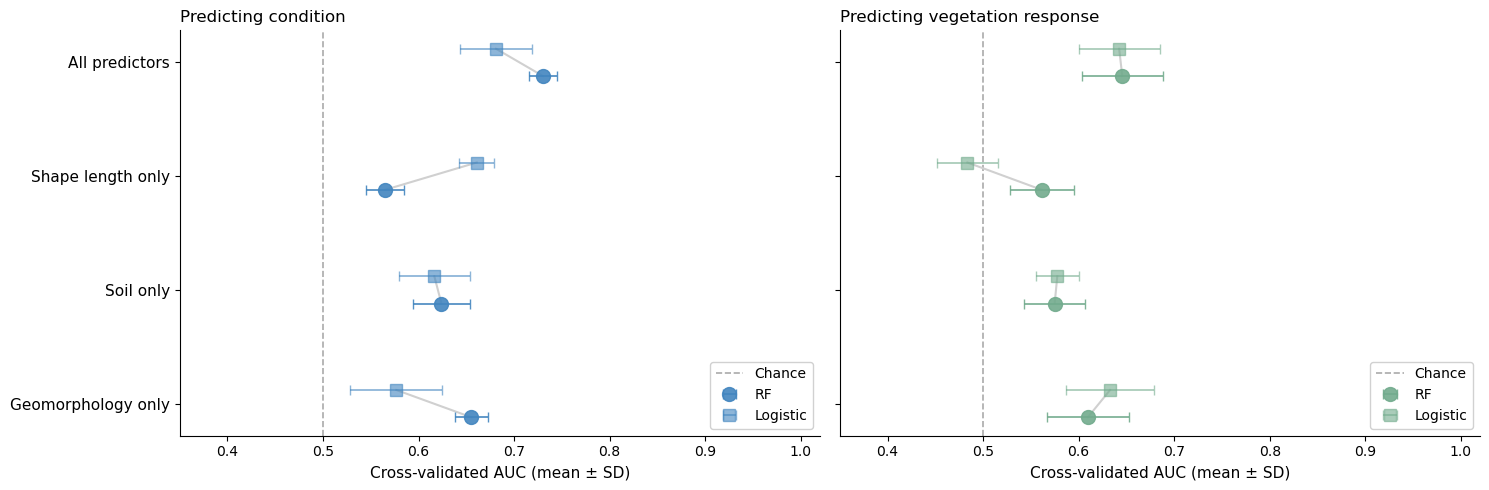

Baseline comparison plotted


In [6]:
# ── 6. Dot-plot: scenario × model × target ────────────────────────────────
_key_order = ['landscape_geomorphology_only', 'soil_only',
              'shape_length_only', 'all_predictors']
_label_map = {
    'landscape_geomorphology_only': 'Geomorphology only',
    'soil_only':                    'Soil only',
    'shape_length_only':            'Shape length only',
    'all_predictors':               'All predictors',
}

fig1, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
_y_pos = np.arange(len(_key_order))
_jitter = 0.12

_clr = {'Intact': MODEL_CLR_CONDITION, 'Effective': MODEL_CLR_VEGRESPONSE}
_marker = {'RF': 'o', 'Logistic': 's'}
_ms = {'RF': 10, 'Logistic': 9}

for ax_idx, _tgt in enumerate(_targets):
    ax = axes[ax_idx]
    _sub = baseline_df[(baseline_df['target'] == _tgt)].copy()
    _sub['order'] = _sub['scenario'].map({s: i for i, s in enumerate(_key_order)})
    _sub = _sub.sort_values('order')

    for _mt_idx, _mt in enumerate(_model_types):
        _rows = _sub[_sub['model'] == _mt]
        _y = _rows['order'].values + (_mt_idx - 0.5) * _jitter * 2
        ax.errorbar(
            _rows['cv_auc_mean'].values, _y,
            xerr=_rows['cv_auc_sd'].values,
            fmt=_marker[_mt], color=_clr[_tgt],
            markersize=_ms[_mt], elinewidth=1.3, capsize=3.5,
            alpha=0.6 if _mt == 'Logistic' else 0.9,
            label=_mt, zorder=3,
        )
        # connect RF–Logistic for same scenario
        for _, _row in _rows.iterrows():
            _rf_row = _sub[(_sub['model'] == 'RF') & (_sub['scenario'] == _row['scenario'])]
            if not _rf_row.empty and _mt == 'Logistic':
                ax.plot(
                    [_rf_row['cv_auc_mean'].values[0], _row['cv_auc_mean']],
                    [_rf_row['order'].values[0] - _jitter,
                     _row['order'] + _jitter],
                    color='#d0d0d0', linewidth=1.5, zorder=1)

    ax.axvline(0.5, color=MODEL_CLR_CHANCE, ls='--', lw=1.2, label='Chance', zorder=0)
    ax.set_yticks(_y_pos)
    ax.set_yticklabels([_label_map[s] for s in _key_order], fontsize=11)
    ax.invert_yaxis()
    ax.set_xlim(0.35, 1.02)
    ax.set_xlabel('Cross-validated AUC (mean ± SD)', fontsize=11)
    ax.set_title(f'Predicting {"condition" if _tgt == "Intact" else "vegetation response"}',
                 fontsize=12, fontweight='normal', loc='left')
    ax.legend(fontsize=10, loc='lower right', framealpha=0.9)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()
print('Baseline comparison plotted')

## Feature selection — RFECV (logistic backbone)

Recursive feature elimination with cross-validation using L2 logistic regression.
Operates on the one-hot-encoded feature space; a predictor is **kept** if
at least one of its dummy columns is selected.

In [7]:
# ── 7. RFECV feature selection on all_predictors ──────────────────────────

def _rfecv_select(predictors, target, treat_as_map=None, random_state=0):
    """
    Run RFECV on the encoded feature matrix and map surviving dummy columns
    back to original predictor names.

    Returns
    -------
    dict  with keys: selected_predictors, rfecv, encoded_feature_names,
          support_mask, col_to_predictor
    """
    treat_as_map = treat_as_map or {}
    sub = df[predictors + [target]].copy()
    sub[target] = _coerce_binary(sub[target])
    sub = sub.dropna(subset=[target])
    X = sub[predictors]
    yv = sub[target].astype(int).values

    # Split categorical / numeric
    cat_cols, num_cols = [], []
    for c in predictors:
        ta = treat_as_map.get(c)
        if ta == 'categorical':
            cat_cols.append(c)
        elif ta == 'numeric':
            num_cols.append(c)
        elif X[c].dtype == object or str(X[c].dtype).startswith('category'):
            cat_cols.append(c)
        else:
            num_cols.append(c)

    pre = ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('impute', SimpleImputer(strategy='median')),
                ('scale', StandardScaler()),
            ]), num_cols),
            ('cat', Pipeline([
                ('impute', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
            ]), cat_cols),
        ],
        remainder='drop',
    )

    X_enc = pre.fit_transform(X)

    # Build encoded column → original predictor mapping
    _enc_names = []
    _col_to_pred = {}
    idx = 0
    for c in num_cols:
        _enc_names.append(c)
        _col_to_pred[idx] = c
        idx += 1
    ohe = pre.named_transformers_['cat'].named_steps['onehot']
    for name in ohe.get_feature_names_out(cat_cols):
        # Match the longest cat_col prefix (handles underscores in names)
        _orig = next(c for c in sorted(cat_cols, key=len, reverse=True)
                     if name.startswith(c + '_'))
        _enc_names.append(name)
        _col_to_pred[idx] = _orig
        idx += 1

    # RFECV with logistic backbone
    _lr = LogisticRegression(
        C=1.0, penalty='l2', max_iter=2000,
        class_weight='balanced', solver='lbfgs', random_state=random_state,
    )
    _cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    _rfecv = RFECV(
        estimator=_lr, step=1, cv=_cv, scoring='roc_auc',
        min_features_to_select=1, n_jobs=-1,
    )
    _rfecv.fit(X_enc, yv)

    # Map selected encoded columns back to original predictors
    _selected_encoded = np.where(_rfecv.support_)[0]
    _selected_orig = sorted(set(_col_to_pred[i] for i in _selected_encoded),
                            key=lambda x: predictors.index(x))

    return {
        'selected_predictors': _selected_orig,
            'rfecv': _rfecv,
        'encoded_feature_names': _enc_names,
        'support_mask': _rfecv.support_,
        'col_to_predictor': _col_to_pred,
        'n_encoded_total': len(_enc_names),
        'n_encoded_selected': int(_rfecv.support_.sum()),
    }


# Run for both targets
rfecv_results = {}
for _tgt in _targets:
    print(f'\n{"="*60}')
    print(f'  RFECV for {_tgt}')
    print(f'{"="*60}')
    _res = _rfecv_select(_all_preds, _tgt, treat_as_map=treat_as)
    rfecv_results[_tgt] = _res
    print(f'  Encoded features: {_res["n_encoded_total"]} → selected: {_res["n_encoded_selected"]}')
    print(f'  Original predictors selected ({len(_res["selected_predictors"])} / {len(_all_preds)}):')
    print(f'    {_res["selected_predictors"]}')
    _dropped = [p for p in _all_preds if p not in _res['selected_predictors']]
    if _dropped:
        print(f'  Dropped: {_dropped}')
    print(f'  Optimal CV AUC: {_res["rfecv"].cv_results_["mean_test_score"].max():.3f}')


  RFECV for Intact
  Encoded features: 49 → selected: 48
  Original predictors selected (8 / 8):
    ['Landform', 'slope_200', 'FA_30_max', 'Texture', 'Soil_Development', 'TypicalProfile', 'Shape_Leng', 'Berm_Length_Class']
  Optimal CV AUC: 0.681

  RFECV for Effective
  Encoded features: 49 → selected: 18
  Original predictors selected (4 / 8):
    ['Landform', 'slope_200', 'Texture', 'TypicalProfile']
  Dropped: ['FA_30_max', 'Soil_Development', 'Shape_Leng', 'Berm_Length_Class']
  Optimal CV AUC: 0.646


In [8]:
# ── 8. Feature selection summary table ────────────────────────────────────
_sel_rows = []
for _p in _all_preds:
    _row = {'Predictor': _clean_predictor_name(_p)}
    for _tgt in _targets:
        _row[f'Selected ({_tgt})'] = _p in rfecv_results[_tgt]['selected_predictors']
    _sel_rows.append(_row)

_sel_table = pd.DataFrame(_sel_rows)
# Style True/False as ✓/✗
for _c in [c for c in _sel_table.columns if c.startswith('Selected')]:
    _sel_table[_c] = _sel_table[_c].map({True: '\u2713', False: '\u2717'})

display(_sel_table)

# Save
os.makedirs('../data/summary', exist_ok=True)
_sel_table.to_csv('../data/summary/rfecv_feature_selection.csv', index=False)
print('Saved: ../data/summary/rfecv_feature_selection.csv')

,Predictor,Selected (Intact),Selected (Effective)
0,Landform,✓,✓
1,Hillslope gradient,✓,✓
2,Flow accumulation,✓,✗
3,Soil texture,✓,✓
4,Soil development,✓,✗
5,Typical soil profile,✓,✓
6,Berm length,✓,✗
7,Berm length class,✓,✗


Saved: ../data/summary/rfecv_feature_selection.csv


## Refit on RFECV-selected features

In [9]:
# ── 9. Refit RF + Logistic on selected features ───────────────────────────
_refit_rows = []
refit_results = {}  # (model_type, target) → (pipe, metrics, pi)

for _tgt in _targets:
    _sel_preds = rfecv_results[_tgt]['selected_predictors']
    for _mt in _model_types:
        print(f'\nRefitting {_mt} for {_tgt} with {len(_sel_preds)} selected predictors...')
        _pipe, _met, _pi = _fit_and_evaluate(
            _mt, _sel_preds, _tgt, treat_as_map=treat_as)
        refit_results[(_mt, _tgt)] = (_pipe, _met, _pi)

        # Before (all_predictors) metrics
        _before_key = ('all_predictors', _mt, _tgt)
        if _before_key in baseline_results:
            _before_auc = baseline_results[_before_key][1]['cv']['auc'][0]
            _before_sd  = baseline_results[_before_key][1]['cv']['auc'][1]
        else:
            _before_auc, _before_sd = np.nan, np.nan

        _after_auc = _met['cv']['auc'][0]
        _after_sd  = _met['cv']['auc'][1]

        _refit_rows.append({
            'model':       _mt,
            'target':      _tgt,
            'n_pred_all':  len(_all_preds),
            'n_pred_sel':  len(_sel_preds),
            'auc_before':  _before_auc,
            'sd_before':   _before_sd,
            'auc_after':   _after_auc,
            'sd_after':    _after_sd,
            'delta_auc':   _after_auc - _before_auc,
        })
        print(f'  AUC: {_before_auc:.3f} → {_after_auc:.3f}  (Δ {_after_auc - _before_auc:+.3f})')

_refit_df = pd.DataFrame(_refit_rows)
display(_refit_df)


Refitting RF for Intact with 8 selected predictors...
  AUC: 0.730 → 0.730  (Δ +0.000)

Refitting Logistic for Intact with 8 selected predictors...
  AUC: 0.681 → 0.681  (Δ +0.000)

Refitting RF for Effective with 4 selected predictors...
  AUC: 0.646 → 0.614  (Δ -0.032)

Refitting Logistic for Effective with 4 selected predictors...
  AUC: 0.642 → 0.642  (Δ -0.000)


,model,target,n_pred_all,n_pred_sel,auc_before,sd_before,auc_after,sd_after,delta_auc
0,RF,Intact,8,8,0.730274,0.015126,0.730274,0.015126,0.000000
1,Logistic,Intact,8,8,0.681095,0.037488,0.681095,0.037488,0.000000
2,RF,Effective,8,4,0.645672,0.042314,0.613714,0.041970,-0.031958
3,Logistic,Effective,8,4,0.642397,0.042531,0.642156,0.043879,-0.000241


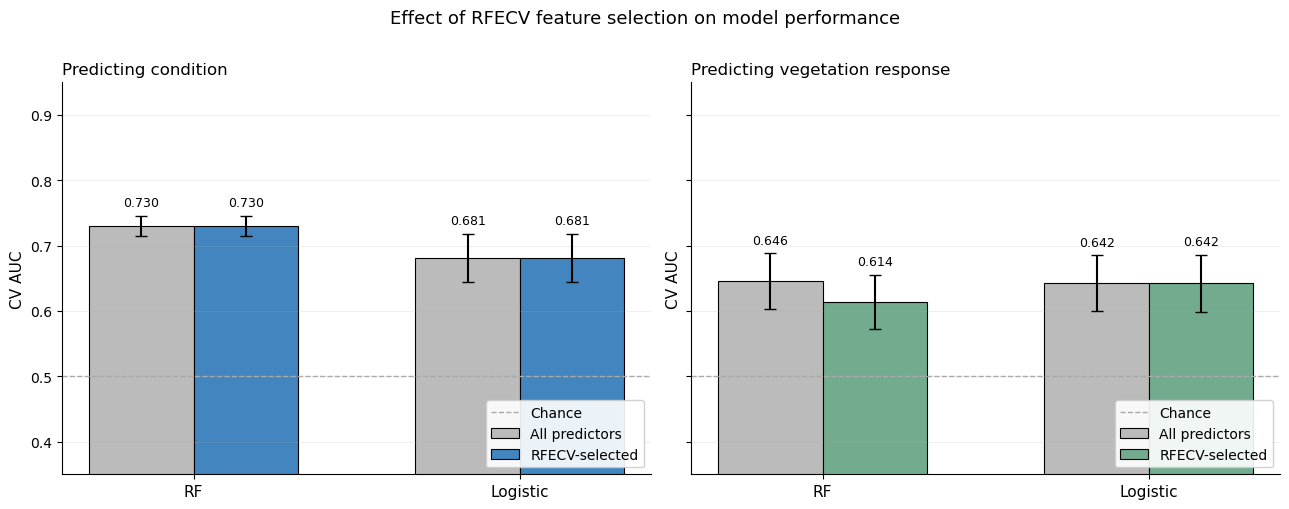

In [10]:
# ── 10. Before vs After feature selection bar chart ────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax_idx, _tgt in enumerate(_targets):
    ax = axes2[ax_idx]
    _sub = _refit_df[_refit_df['target'] == _tgt]
    _x = np.arange(len(_model_types))
    _w = 0.32

    _clr_before = '#bbbbbb'
    _clr_after  = MODEL_CLR_CONDITION if _tgt == 'Intact' else MODEL_CLR_VEGRESPONSE

    for i, _mt in enumerate(_model_types):
        _r = _sub[_sub['model'] == _mt].iloc[0]
        ax.bar(i - _w/2, _r['auc_before'], _w, yerr=_r['sd_before'],
               color=_clr_before, edgecolor='black', lw=0.8, capsize=4,
               label='All predictors' if i == 0 else '')
        ax.bar(i + _w/2, _r['auc_after'], _w, yerr=_r['sd_after'],
               color=_clr_after, edgecolor='black', lw=0.8, capsize=4,
               label='RFECV-selected' if i == 0 else '')
        # value labels
        ax.text(i - _w/2, _r['auc_before'] + _r['sd_before'] + 0.01,
                f'{_r["auc_before"]:.3f}', ha='center', va='bottom', fontsize=9)
        ax.text(i + _w/2, _r['auc_after'] + _r['sd_after'] + 0.01,
                f'{_r["auc_after"]:.3f}', ha='center', va='bottom', fontsize=9)

    ax.axhline(0.5, color=MODEL_CLR_CHANCE, ls='--', lw=1, label='Chance')
    ax.set_xticks(_x)
    ax.set_xticklabels(_model_types, fontsize=11)
    ax.set_ylabel('CV AUC', fontsize=11)
    ax.set_ylim(0.35, 0.95)
    ax.set_title(f'Predicting {"condition" if _tgt == "Intact" else "vegetation response"}',
                 fontsize=12, fontweight='normal', loc='left')
    ax.legend(fontsize=10, loc='lower right', framealpha=0.9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.2)

fig2.suptitle('Effect of RFECV feature selection on model performance',
              fontsize=13, fontweight='normal', y=1.01)
plt.tight_layout()
plt.show()

## Feature importance — RF permutation vs Logistic coefficients

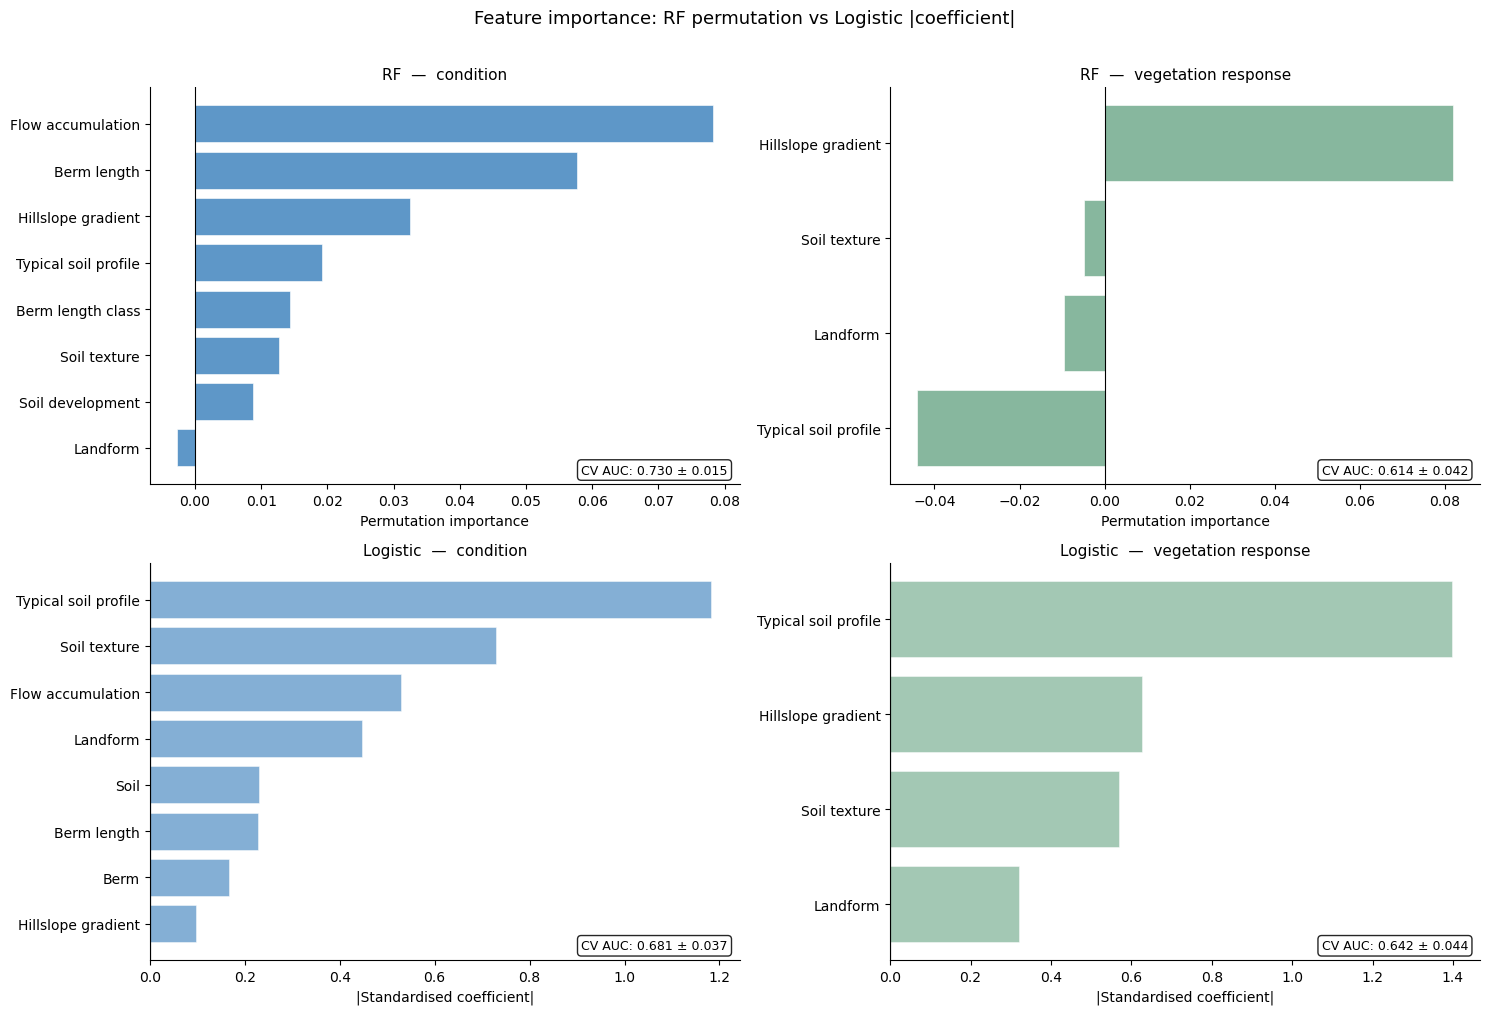

In [11]:
# ── 11. Feature importance comparison ─────────────────────────────────────

def _logistic_coef_importance(pipe, predictors, treat_as_map=None):
    """
    Extract absolute logistic coefficients from a fitted pipeline and
    aggregate back to original predictor level (max |coef| per predictor).
    """
    treat_as_map = treat_as_map or {}
    coefs = pipe.named_steps['clf'].coef_.ravel()
    pre = pipe.named_steps['pre']

    # Rebuild encoded col → original predictor map
    cat_cols, num_cols = [], []
    for c in predictors:
        ta = treat_as_map.get(c)
        if ta == 'categorical':
            cat_cols.append(c)
        elif ta == 'numeric':
            num_cols.append(c)
        elif df[c].dtype == object or str(df[c].dtype).startswith('category'):
            cat_cols.append(c)
        else:
            num_cols.append(c)

    _agg = {}
    idx = 0
    for c in num_cols:
        _agg[c] = abs(coefs[idx])
        idx += 1
    ohe = pre.named_transformers_['cat'].named_steps['onehot']
    for name in ohe.get_feature_names_out(cat_cols):
        _orig = name.split('_', 1)[0]
        _agg[_orig] = max(_agg.get(_orig, 0), abs(coefs[idx]))
        idx += 1

    return pd.Series(_agg).sort_values(ascending=False)


fig3, axes3 = plt.subplots(2, 2, figsize=(15, 10))

_N_FEAT = 8

for col_idx, _tgt in enumerate(_targets):
    _sel_preds = rfecv_results[_tgt]['selected_predictors']
    _clr = MODEL_CLR_CONDITION if _tgt == 'Intact' else MODEL_CLR_VEGRESPONSE
    _tgt_label = 'condition' if _tgt == 'Intact' else 'vegetation response'

    # ── Row 0: RF permutation importance
    _ax_rf = axes3[0, col_idx]
    _pi_rf = refit_results[('RF', _tgt)][2].head(_N_FEAT)
    _pi_rf_pretty = _pi_rf.rename(index=lambda x: _clean_predictor_name(x))
    _y = np.arange(len(_pi_rf_pretty))
    _ax_rf.barh(_y, _pi_rf_pretty.values, color=_clr, alpha=0.85,
                edgecolor='white', lw=0.5)
    _ax_rf.set_yticks(_y)
    _ax_rf.set_yticklabels(_pi_rf_pretty.index, fontsize=10)
    _ax_rf.invert_yaxis()
    _ax_rf.axvline(0, color='black', lw=0.8)
    _ax_rf.set_xlabel('Permutation importance', fontsize=10)
    _ax_rf.set_title(f'RF  —  {_tgt_label}', fontsize=11)
    _ax_rf.spines[['top', 'right']].set_visible(False)
    _auc_rf = refit_results[('RF', _tgt)][1]['cv']['auc']
    _ax_rf.text(0.98, 0.02, f'CV AUC: {_auc_rf[0]:.3f} ± {_auc_rf[1]:.3f}',
               transform=_ax_rf.transAxes, ha='right', va='bottom', fontsize=9,
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

    # ── Row 1: Logistic |coefficient|
    _ax_lr = axes3[1, col_idx]
    _pipe_lr = refit_results[('Logistic', _tgt)][0]
    _coef_imp = _logistic_coef_importance(_pipe_lr, _sel_preds, treat_as).head(_N_FEAT)
    _coef_pretty = _coef_imp.rename(index=lambda x: _clean_predictor_name(x))
    _y2 = np.arange(len(_coef_pretty))
    _ax_lr.barh(_y2, _coef_pretty.values, color=_clr, alpha=0.65,
                edgecolor='white', lw=0.5)
    _ax_lr.set_yticks(_y2)
    _ax_lr.set_yticklabels(_coef_pretty.index, fontsize=10)
    _ax_lr.invert_yaxis()
    _ax_lr.axvline(0, color='black', lw=0.8)
    _ax_lr.set_xlabel('|Standardised coefficient|', fontsize=10)
    _ax_lr.set_title(f'Logistic  —  {_tgt_label}', fontsize=11)
    _ax_lr.spines[['top', 'right']].set_visible(False)
    _auc_lr = refit_results[('Logistic', _tgt)][1]['cv']['auc']
    _ax_lr.text(0.98, 0.02, f'CV AUC: {_auc_lr[0]:.3f} ± {_auc_lr[1]:.3f}',
               transform=_ax_lr.transAxes, ha='right', va='bottom', fontsize=9,
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

fig3.suptitle('Feature importance: RF permutation vs Logistic |coefficient|',
              fontsize=13, fontweight='normal', y=1.01)
plt.tight_layout()
plt.show()

In [12]:
# ── 12. Save figures and register ─────────────────────────────────────────
_fig_dir = os.path.join('..', 'figures', 'outcomes')
os.makedirs(_fig_dir, exist_ok=True)

# ── Save Fig 1: baseline scenario sweep
_name1 = 'fig_model_comparison_scenarios.png'
fig1.savefig(os.path.join(_fig_dir, _name1), dpi=300, bbox_inches='tight')

# Build dynamic description strings
_all_intact_rf  = baseline_results.get(('all_predictors', 'RF', 'Intact'), (None, {'cv': {'auc': (np.nan, np.nan)}}))[1]['cv']['auc']
_all_intact_lr  = baseline_results.get(('all_predictors', 'Logistic', 'Intact'), (None, {'cv': {'auc': (np.nan, np.nan)}}))[1]['cv']['auc']
_all_eff_rf     = baseline_results.get(('all_predictors', 'RF', 'Effective'), (None, {'cv': {'auc': (np.nan, np.nan)}}))[1]['cv']['auc']
_all_eff_lr     = baseline_results.get(('all_predictors', 'Logistic', 'Effective'), (None, {'cv': {'auc': (np.nan, np.nan)}}))[1]['cv']['auc']

register_outcomes_figure(
    'fig_model_comparison_scenarios',
    'Model comparison — scenario sweep',
    _name1,
    f"""Dot-plot comparing RF and Logistic L2 across four predictor scenarios for both outcomes.
All-predictors: Condition RF AUC {_all_intact_rf[0]:.3f} ± {_all_intact_rf[1]:.3f}, Logistic {_all_intact_lr[0]:.3f} ± {_all_intact_lr[1]:.3f}.
All-predictors: Veg response RF AUC {_all_eff_rf[0]:.3f} ± {_all_eff_rf[1]:.3f}, Logistic {_all_eff_lr[0]:.3f} ± {_all_eff_lr[1]:.3f}.""",
    f"""RF and Logistic L2 compared across 4 predictor scenarios. All-predictors condition AUC: RF {_all_intact_rf[0]:.3f}, Logistic {_all_intact_lr[0]:.3f}."""
)
print(f'Saved: {_name1}')

# ── Save Fig 2: before vs after feature selection
_name2 = 'fig_rfecv_feature_selection.png'
fig2.savefig(os.path.join(_fig_dir, _name2), dpi=300, bbox_inches='tight')

_n_sel_int = len(rfecv_results['Intact']['selected_predictors'])
_n_sel_eff = len(rfecv_results['Effective']['selected_predictors'])

register_outcomes_figure(
    'fig_rfecv_feature_selection',
    'RFECV feature selection effect',
    _name2,
    f"""Bar chart showing CV AUC before (all {len(_all_preds)} predictors) and after RFECV selection for RF and Logistic.
Condition: RFECV selected {_n_sel_int} predictors. Veg response: RFECV selected {_n_sel_eff} predictors.""",
    f"""RFECV reduces predictors ({len(_all_preds)} → {_n_sel_int} for condition, {_n_sel_eff} for veg response) with minimal AUC change."""
)
print(f'Saved: {_name2}')

# ── Save Fig 3: feature importance
_name3 = 'fig_model_feature_importance.png'
fig3.savefig(os.path.join(_fig_dir, _name3), dpi=300, bbox_inches='tight')

_top_rf_int = ', '.join(refit_results[('RF', 'Intact')][2].head(3).index.tolist())
_top_rf_eff = ', '.join(refit_results[('RF', 'Effective')][2].head(3).index.tolist())

register_outcomes_figure(
    'fig_model_feature_importance',
    'Feature importance — RF vs Logistic',
    _name3,
    f"""2×2 feature importance panel: RF permutation importance (top row) and Logistic |coefficient| (bottom row) for Condition and Veg response.
Top RF predictors for Condition: {_top_rf_int}. Top RF predictors for Veg response: {_top_rf_eff}.""",
    f"""RF vs Logistic feature importance: top condition predictors are {_top_rf_int}; top veg response predictors are {_top_rf_eff}."""
)
print(f'Saved: {_name3}')

print('\nAll figures saved and registered.')

Updated → ../latex/figure_report_outcomes.tex  (Model comparison — scenario sweep)
Saved: fig_model_comparison_scenarios.png
Updated → ../latex/figure_report_outcomes.tex  (RFECV feature selection effect)
Saved: fig_rfecv_feature_selection.png
Updated → ../latex/figure_report_outcomes.tex  (Feature importance — RF vs Logistic)
Saved: fig_model_feature_importance.png

All figures saved and registered.
